<a href="https://colab.research.google.com/github/EcTrailblazers/python-data-projects/blob/main/10_plfs_employment_audit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Data modeled on MoSPI Annual PLFS Reports (Ages 15+)
# LFPR = Labour Force Participation Rate (%)
# WPR  = Worker Population Ratio (%)
# UR   = Unemployment Rate (%)
raw_plfs_data = """Survey_Year,Region,Gender,LFPR_%,WPR_%,UR_%,Self_Employed_%,Regular_Wage_%,Casual_Labor_%
2020-21,Rural,Male,78.1,75.2,3.8,59.8,12.5,27.7
2020-21,Rural,Female,33.0,32.2,2.1,75.1,8.3,16.6
2020-21,Urban,Male,73.8,69.2,6.1,39.9,46.5,13.6
2020-21,Urban,Female,22.9,20.9,8.6,40.1,44.2,15.7
2021-22,Rural,Male,78.3,75.3,3.8,61.0,12.1,26.9
2021-22,Rural,Female,36.6,35.8,2.1,76.2,7.9,15.9
2021-22,Urban,Male,74.7,70.3,5.8,39.8,47.1,13.1
2021-22,Urban,Female,23.8,21.9,7.9,38.5,46.2,15.3
2022-23,Rural,Male,80.2,77.7,3.1,62.2,12.4,25.4
2022-23,Rural,Female,41.5,40.7,1.8,77.5,7.2,15.3
2022-23,Urban,Male,74.5,71.0,4.7,40.3,47.8,11.9
2022-23,Urban,Female,25.4,23.5,7.5,37.9,48.0,14.1
"""

with open("plfs_employment_data.csv", "w") as f:
    f.write(raw_plfs_data.strip())

print("plfs_employment_data.csv created successfully.")

plfs_employment_data.csv created successfully.


In [2]:
df_plfs = pd.read_csv("plfs_employment_data.csv")

# 1. Pivot table: Average LFPR across Region and Gender over the survey years
lfpr_pivot = df_plfs.pivot_table(
    index="Survey_Year",
    columns=["Region", "Gender"],
    values="LFPR_%",
    aggfunc="mean",
)

# 2. Derive Gender Gap in Labour Force Participation (Male minus Female)
df_gap = (
    df_plfs.pivot(
        index=["Survey_Year", "Region"], columns="Gender", values="LFPR_%"
    )
    .reset_index()
)
df_gap["Gender_LFPR_Gap"] = df_gap["Male"] - df_gap["Female"]

print("--- Multi-Index LFPR Summary Pivot ---")
print(lfpr_pivot.round(2))
print("\n--- Gender Gap Trajectory ---")
print(df_gap[["Survey_Year", "Region", "Male", "Female", "Gender_LFPR_Gap"]])

--- Multi-Index LFPR Summary Pivot ---
Region       Rural        Urban      
Gender      Female  Male Female  Male
Survey_Year                          
2020-21       33.0  78.1   22.9  73.8
2021-22       36.6  78.3   23.8  74.7
2022-23       41.5  80.2   25.4  74.5

--- Gender Gap Trajectory ---
Gender Survey_Year Region  Male  Female  Gender_LFPR_Gap
0          2020-21  Rural  78.1    33.0             45.1
1          2020-21  Urban  73.8    22.9             50.9
2          2021-22  Rural  78.3    36.6             41.7
3          2021-22  Urban  74.7    23.8             50.9
4          2022-23  Rural  80.2    41.5             38.7
5          2022-23  Urban  74.5    25.4             49.1


In [3]:
latest_plfs = df_plfs[df_plfs["Survey_Year"] == "2022-23"].copy()

# Add a composite demographic label
latest_plfs["Demographic"] = (
    latest_plfs["Region"] + " " + latest_plfs["Gender"]
)

# Audit employment nature shares
work_profile = latest_plfs[
    [
        "Demographic",
        "LFPR_%",
        "WPR_%",
        "UR_%",
        "Self_Employed_%",
        "Regular_Wage_%",
        "Casual_Labor_%",
    ]
].set_index("Demographic")

print("--- 2022-23 Workforce Structural Profile ---")
print(work_profile.round(2))

--- 2022-23 Workforce Structural Profile ---
              LFPR_%  WPR_%  UR_%  Self_Employed_%  Regular_Wage_%  \
Demographic                                                          
Rural Male      80.2   77.7   3.1             62.2            12.4   
Rural Female    41.5   40.7   1.8             77.5             7.2   
Urban Male      74.5   71.0   4.7             40.3            47.8   
Urban Female    25.4   23.5   7.5             37.9            48.0   

              Casual_Labor_%  
Demographic                   
Rural Male              25.4  
Rural Female            15.3  
Urban Male              11.9  
Urban Female            14.1  


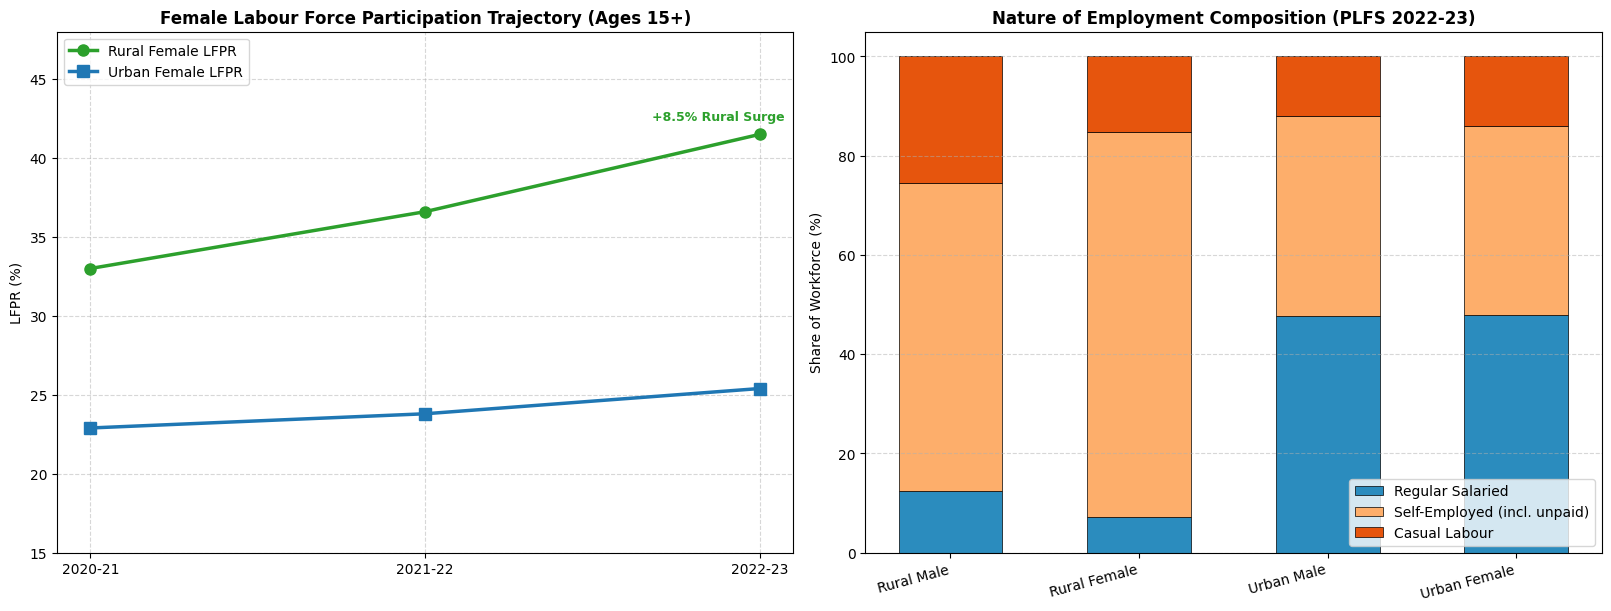

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), layout="constrained")

# --- Chart 1: Female LFPR Trajectory Across Rural vs. Urban India ---
female_trends = df_plfs[df_plfs["Gender"] == "Female"]

for region, color, marker in [
    ("Rural", "#2ca02c", "o"),
    ("Urban", "#1f77b4", "s"),
]:
    subset = female_trends[female_trends["Region"] == region]
    ax1.plot(
        subset["Survey_Year"],
        subset["LFPR_%"],
        label=f"{region} Female LFPR",
        color=color,
        linewidth=2.5,
        marker=marker,
        markersize=8,
    )

ax1.set_title(
    "Female Labour Force Participation Trajectory (Ages 15+)",
    fontsize=12,
    weight="bold",
)
ax1.set_ylabel("LFPR (%)")
ax1.set_ylim(15, 48)
ax1.grid(True, linestyle="--", alpha=0.5)
ax1.legend(loc="upper left")

# Annotate Rural surge
rural_latest = female_trends[
    (female_trends["Region"] == "Rural")
    & (female_trends["Survey_Year"] == "2022-23")
]["LFPR_%"].values[0]
ax1.annotate(
    f"+{rural_latest - 33.0:.1f}% Rural Surge",
    ("2022-23", rural_latest),
    textcoords="offset points",
    xytext=(-30, 10),
    ha="center",
    fontsize=9,
    weight="bold",
    color="#2ca02c",
)

# --- Chart 2: Quality of Employment Breakdown (2022-23) ---
categories = latest_plfs["Demographic"]
x = np.arange(len(categories))
width = 0.55

p1 = ax2.bar(
    x,
    latest_plfs["Regular_Wage_%"],
    width,
    label="Regular Salaried",
    color="#2b8cbe",
    edgecolor="black",
    linewidth=0.5,
)
p2 = ax2.bar(
    x,
    latest_plfs["Self_Employed_%"],
    width,
    bottom=latest_plfs["Regular_Wage_%"],
    label="Self-Employed (incl. unpaid)",
    color="#fdae6b",
    edgecolor="black",
    linewidth=0.5,
)
p3 = ax2.bar(
    x,
    latest_plfs["Casual_Labor_%"],
    width,
    bottom=latest_plfs["Regular_Wage_%"] + latest_plfs["Self_Employed_%"],
    label="Casual Labour",
    color="#e6550d",
    edgecolor="black",
    linewidth=0.5,
)

ax2.set_title(
    "Nature of Employment Composition (PLFS 2022-23)",
    fontsize=12,
    weight="bold",
)
ax2.set_ylabel("Share of Workforce (%)")
ax2.set_xticks(x)
ax2.set_xticklabels(categories, rotation=15, ha="right")
ax2.set_ylim(0, 105)
ax2.grid(axis="y", linestyle="--", alpha=0.5)
ax2.legend(loc="lower right")

plt.show()